<a href="https://colab.research.google.com/github/NayanthaDhasun/NorthStar_Database_Analytics/blob/main/R_SQL_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacity_score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the col

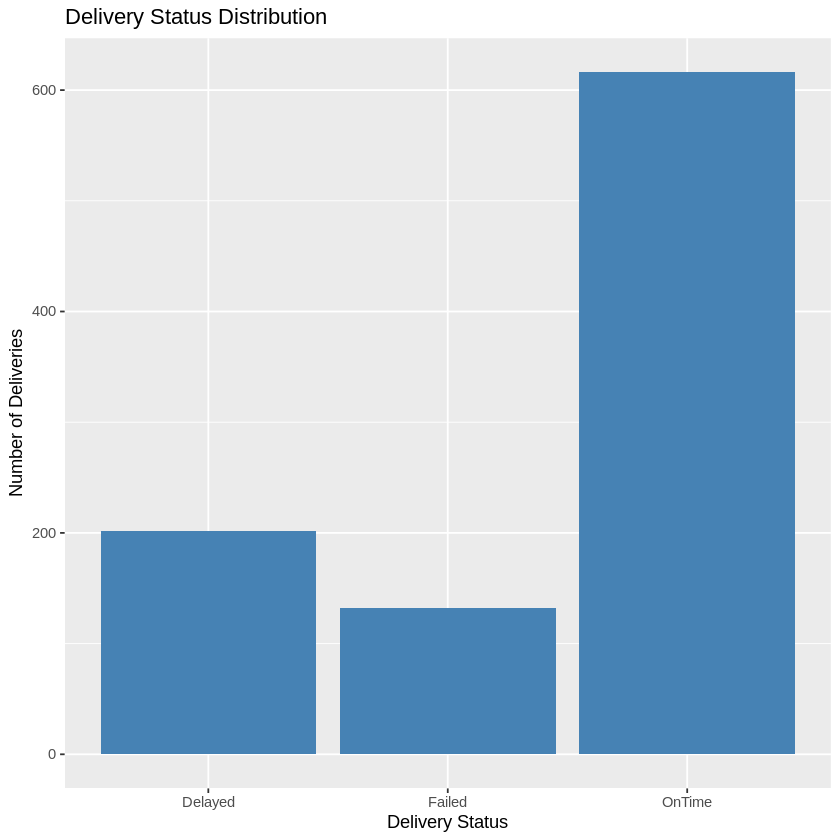

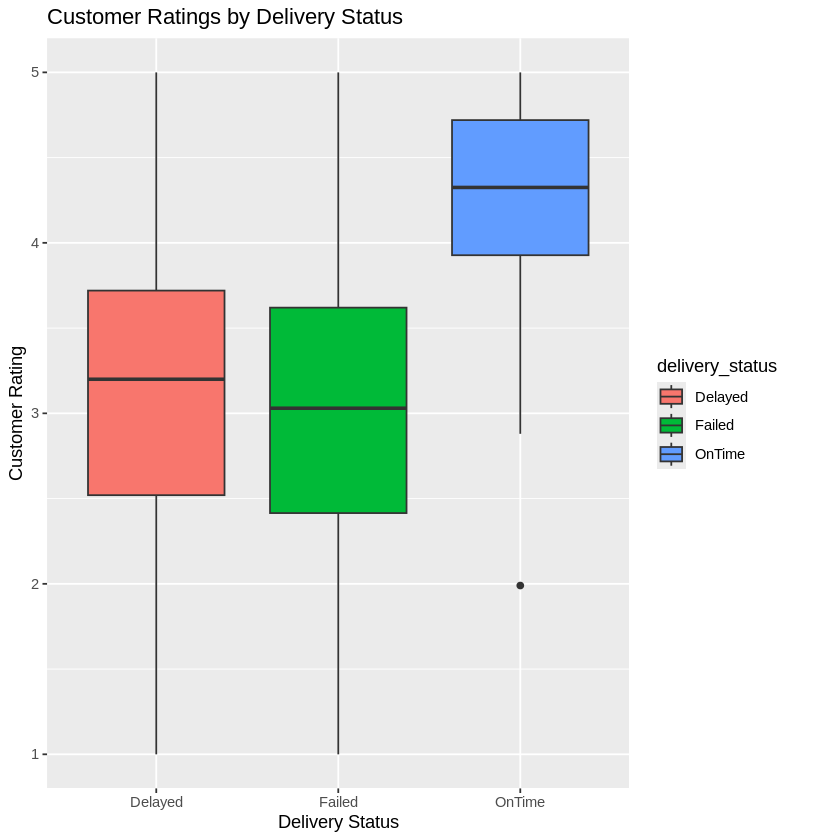

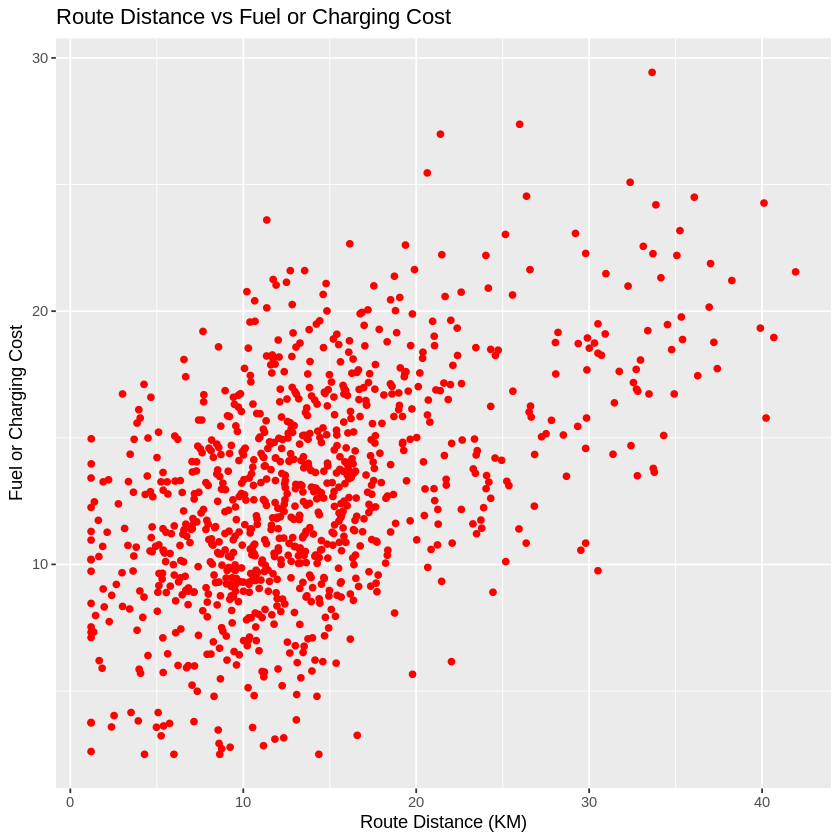

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_summary()`).”


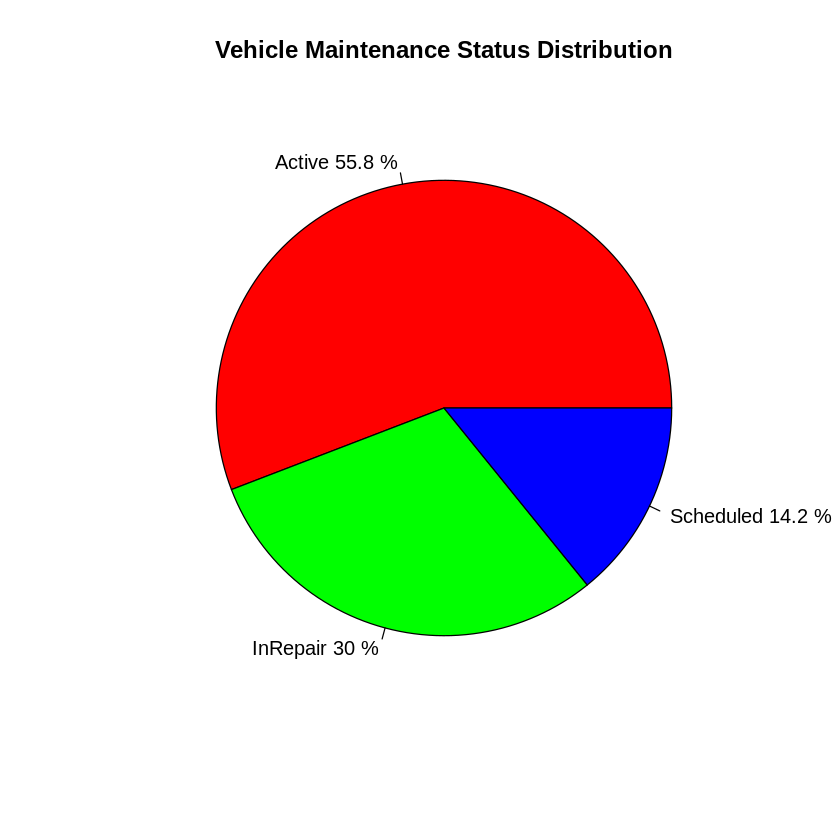

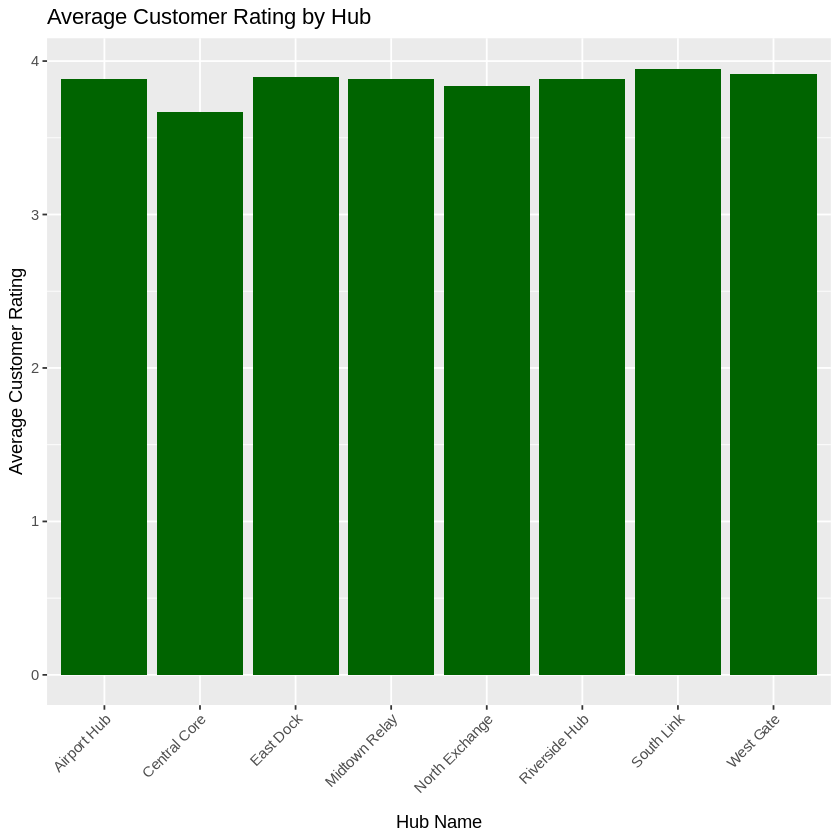

In [ ]:
install.packages("readr")
install.packages("dplyr")
install.packages("ggplot2")

library(readr)
library(dplyr)
library(ggplot2)

deliveries <- read_csv("deliveries.csv")
hubs <- read_csv("hubs.csv")
drivers <- read_csv("drivers.csv")
vehicles <- read_csv("vehicles.csv")
complaints <- read_csv("complaints.csv")

ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  )

  ggplot(deliveries,
       aes(x = delivery_status,
           y = customer_rating_post_delivery,
           fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Customer Ratings by Delivery Status",
    x = "Delivery Status",
    y = "Customer Rating"
  )



  ggplot(deliveries,
       aes(x = route_distance_km,
           y = fuel_or_charge_cost)) +
  geom_point(color = "red") +
  labs(
    title = "Route Distance vs Fuel or Charging Cost",
    x = "Route Distance (KM)",
    y = "Fuel or Charging Cost"
  )


vehicle_counts <- as.data.frame(table(vehicles$maintenance_status))

pie(
  vehicle_counts$Freq,
  labels = paste(vehicle_counts$Var1,
                 round(vehicle_counts$Freq / sum(vehicle_counts$Freq) * 100, 1),
                 "%"),
  main = "Vehicle Maintenance Status Distribution",
  col = rainbow(length(vehicle_counts$Freq))
)


  hub_ratings <- merge(deliveries, hubs, by = "hub_id")

ggplot(hub_ratings,
       aes(x = hub_name,
           y = customer_rating_post_delivery)) +
  geom_bar(stat = "summary",
           fun = "mean",
           fill = "darkgreen") +
  labs(
    title = "Average Customer Rating by Hub",
    x = "Hub Name",
    y = "Average Customer Rating"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))